In [1]:
from pathlib import Path

folder_path = Path("C://Users//X//projects//deepwings//test")
print(folder_path)

C:\Users\X\projects\deepwings\test


In [2]:
import random
import os
from pathlib import Path

directory = folder_path
mask_directory = Path(str(folder_path).replace("test", "test_masks"))

all_files = []
for subdir, _, files in os.walk(directory):
    for file in files:
        if file.lower().endswith(".jpg"):
            path = Path(os.path.join(subdir, file))
            all_files.append(path)

all_masks = []
missing_masks = []
for img_path in all_files:
    mask_path = Path(str(img_path).replace("test", "test_masks"))
    if mask_path.exists():
        all_masks.append(mask_path)
    else:
        missing_masks.append(img_path)

print(f"Images: {len(all_files)}, Masks: {len(all_masks)}, Missing masks: {len(missing_masks)}")
if missing_masks:
    print("Missing masks for:")
    for p in missing_masks:
        print(" ", p)

sample_path = random.choice(all_files)
sample_mask_path = Path(str(sample_path).replace("test", "test_masks"))
sample_path, sample_mask_path

Images: 3510, Masks: 3510, Missing masks: 0


(WindowsPath('C:/Users/X/projects/deepwings/test/2411.3-f.jpg'),
 WindowsPath('C:/Users/X/projects/deepwings/test_masks/2411.3-f.jpg'))

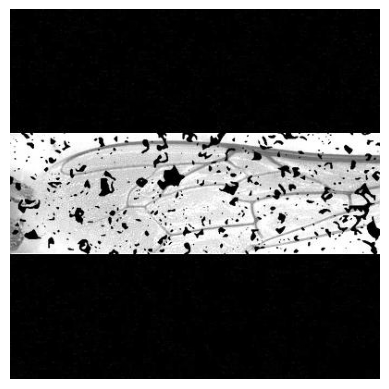

In [3]:
import cv2
import torch
import matplotlib.pyplot as plt

img = cv2.imread(str(sample_path))
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img = cv2.flip(img, 1)

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()


In [4]:
import torchvision.transforms.functional as F

img_tensor = torch.from_numpy(img).unsqueeze(0).contiguous()
img_tensor = F.convert_image_dtype(img_tensor, torch.float)
m, s = img_tensor.mean(dim=(1, 2)), img_tensor.std(dim=(1, 2))
image_tensor = F.normalize(img_tensor, mean=m, std=s)

In [5]:
from wings.modeling.loss import DiceLoss, WeightedDiceLoss, BCEDiceLoss
from wings.modeling.litnet import LitNet
from wings.config import PROCESSED_DATA_DIR, MODELS_DIR
from wings.modeling.unet import UNet
import torch

mean_coords = torch.load(
    PROCESSED_DATA_DIR / "mask_datasets" / 'rectangle' / "mean_shape.pth", weights_only=False
)

checkpoint_path = MODELS_DIR / "new_unet" / "unet-final-k5.ckpt"

unet_model = UNet(in_channels=1, out_channels=1, kernel_size=5)
model = LitNet.load_from_checkpoint(checkpoint_path, model=unet_model, criterion=BCEDiceLoss(), strict=False)
model.eval()


2026-06-27 13:02:32.184 | INFO     | wings.config:<module>:44 - PROJ_ROOT path is: C:\Users\X\projects\bees
2026-06-27 13:02:33.995 | INFO     | wings.config:<module>:68 - torch.cuda.get_device_name()='NVIDIA RTX A3000 12GB Laptop GPU'
W0627 13:02:34.992000 8796 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


LitNet(
  (model): UNet(
    (encoder1): Sequential(
      (enc1conv1): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False)
      (enc1norm1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (enc1relu1): ReLU(inplace=True)
      (enc1conv2): Conv2d(32, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False)
      (enc1norm2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (enc1relu2): ReLU(inplace=True)
    )
    (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (encoder2): Sequential(
      (enc2conv1): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False)
      (enc2norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (enc2relu1): ReLU(inplace=True)
      (enc2conv2): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False)
      (enc2norm2): BatchNor

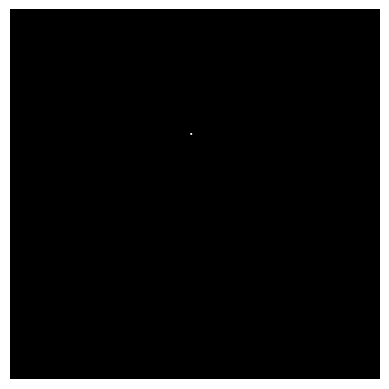

In [6]:
with torch.inference_mode():
    output = model(image_tensor.cuda().unsqueeze(0))
mask = torch.round(output).squeeze().detach().cpu().numpy()

plt.imshow(mask, cmap="gray")
plt.axis("off")
plt.show()

In [7]:
from wings.visualizing.image_preprocess import mask_to_coords

mask_coords = mask_to_coords(mask)
mask_coords = torch.tensor(mask_coords)
print(len(mask_coords))
mask_coords

1


tensor([[195.5000, 264.5000]])

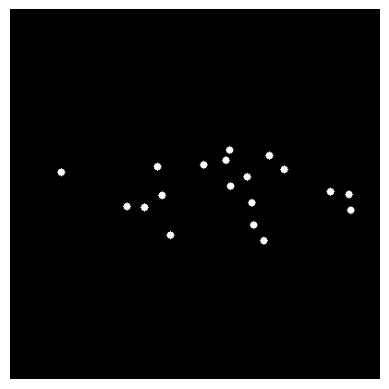

In [8]:
gt_mask = cv2.imread(str(sample_mask_path))
gt_mask = cv2.cvtColor(gt_mask, cv2.COLOR_BGR2GRAY)
gt_mask = cv2.flip(gt_mask, 1)

plt.imshow(gt_mask, cmap="gray")
plt.axis("off")
plt.show()

In [10]:
from tqdm.notebook import tqdm

count_19 = 0
failed = []

with torch.inference_mode():
    for img_path in tqdm(all_files):
        try:
            img = cv2.imread(str(img_path))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img = cv2.flip(img, 1)

            img_tensor = torch.from_numpy(img).unsqueeze(0).contiguous()
            img_tensor = F.convert_image_dtype(img_tensor, torch.float)
            m, s = img_tensor.mean(dim=(1, 2)), img_tensor.std(dim=(1, 2))
            img_tensor = F.normalize(img_tensor, mean=m, std=s)

            output = model(img_tensor.cuda().unsqueeze(0))
            mask = torch.round(output).squeeze().detach().cpu().numpy()

            coords = mask_to_coords(mask)
            if len(coords) >= 18 and len(coords) <= 21:
                count_19 += 1
        except Exception as e:
            failed.append((img_path, str(e)))

print(f"Images with exactly 19 points: {count_19} / {len(all_files)}")
if failed:
    print(f"Failed: {len(failed)}")
    for p, e in failed:
        print(f"  {p}: {e}")

  0%|          | 0/3510 [00:00<?, ?it/s]

Images with exactly 19 points: 484 / 3510
